In [1]:
import pandas as pd
fruits = pd.read_csv('../data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


In [2]:
fruits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
 2   name    49 non-null     object 
dtypes: float64(2), object(1)
memory usage: 1.3+ KB


In [4]:
# 사과 정보 불러오기
apple = fruits[:35]
apple.tail()

,length,weight,name
30,38.5,920.0,apple
31,38.5,955.0,apple
32,39.5,925.0,apple
33,41.0,975.0,apple
34,41.0,950.0,apple


### apple의 산포도

In [5]:
import matplotlib.pyplot as plt

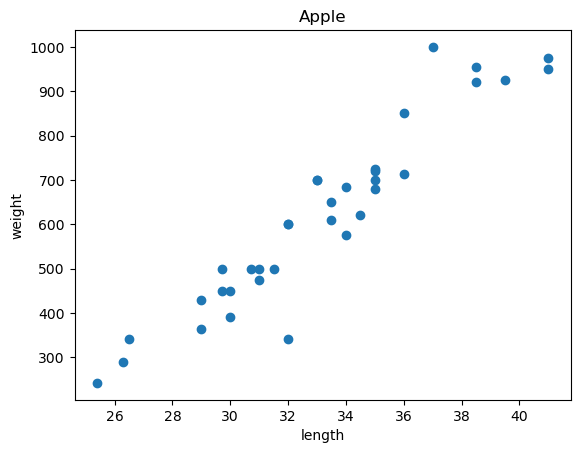

In [7]:
plt.scatter(
    apple['length'],
    apple['weight']
)

plt.xlabel('length')
plt.ylabel('weight')
plt.title('Apple')

plt.show()

In [8]:
berry = fruits[35:]
berry.head()

,length,weight,name
35,9.8,6.7,berry
36,10.5,7.5,berry
37,10.6,7.0,berry
38,11.0,9.7,berry
39,11.2,9.8,berry


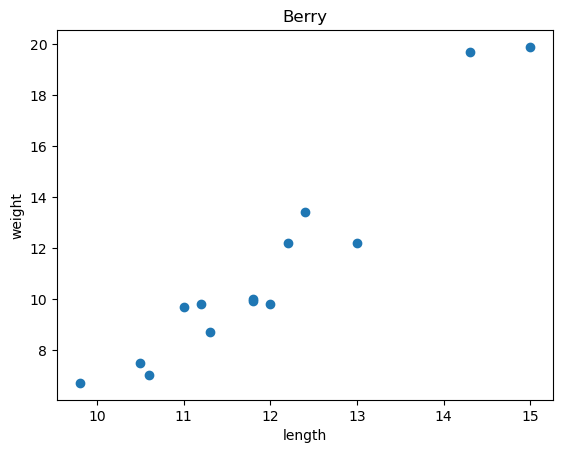

In [9]:
plt.scatter(
    berry['length'],
    berry['weight']
)

plt.xlabel('length')
plt.ylabel('weight')
plt.title('Berry')

plt.show()

In [13]:
color_tmp = []

for name in fruits['name']:
    if name == 'apple':
        color_tmp.append('red')
    else:
        color_tmp.append('blue')

fruits['color'] = color_tmp

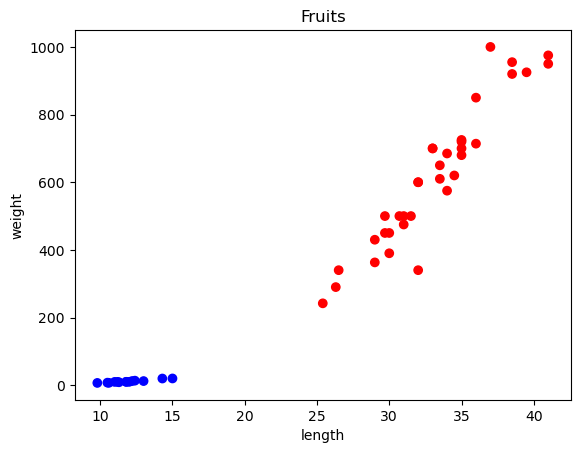

In [14]:
# fruits 산포도 그리기
plt.scatter(
    fruits['length'],
    fruits['weight'],
    c=fruits['color']
)

plt.xlabel('length')
plt.ylabel('weight')
plt.title('Fruits')

plt.show()

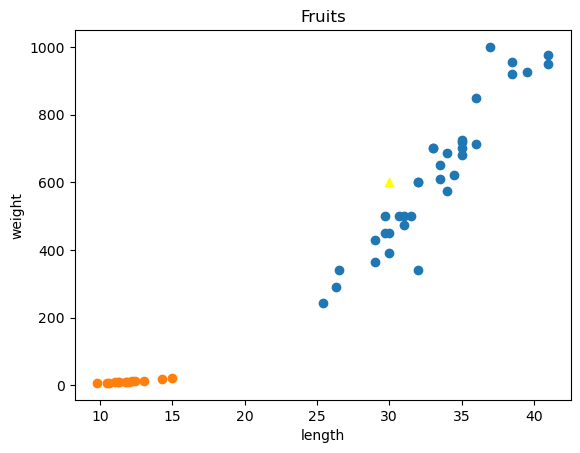

In [32]:
# 2개의 Dataset을 산포도로 한꺼번에 비교하기

plt.scatter(
    apple.length,
    apple.weight
)
plt.scatter(
    berry.length,
    berry.weight
)
plt.scatter(
    30,
    600,
    c='yellow',
    marker = '^'
)

plt.xlabel('length')
plt.ylabel('weight')
plt.title('Fruits')

plt.show()

#### 머신러닝을 위한 데이터 준비

- Feature Data와 Target Data 분리

In [19]:
# fruits Data
fruitsData = \
    fruits[
        [
            'length',
            'weight'
        ]
    ]
fruitsData.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [22]:
# target Data
fruitsTarget = \
    fruits[
        'name'
    ]
fruitsTarget.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

### 최근접이웃(kNN : k Nearest Neighbors) 분류 알고리즘
- k는 얼마인지 모르는 미지수

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
# Model 생성
kn = KNeighborsClassifier() # kNN의 Hyper Parameter의 default 값은 5 : 반드시 홀수로 해야 함 | 조정 : n_neighbors=3

In [25]:
# 학습시키기
kn.fit(fruitsData, fruitsTarget)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
# 정확도
kn.score(fruitsData, fruitsTarget)

1.0

In [31]:
# 예측해보기
# 길이가 30cm이고 무게가 600g인것은 무엇인가?
kn.predict([[30, 600]])[0]

c:\Users\tuxca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'apple'